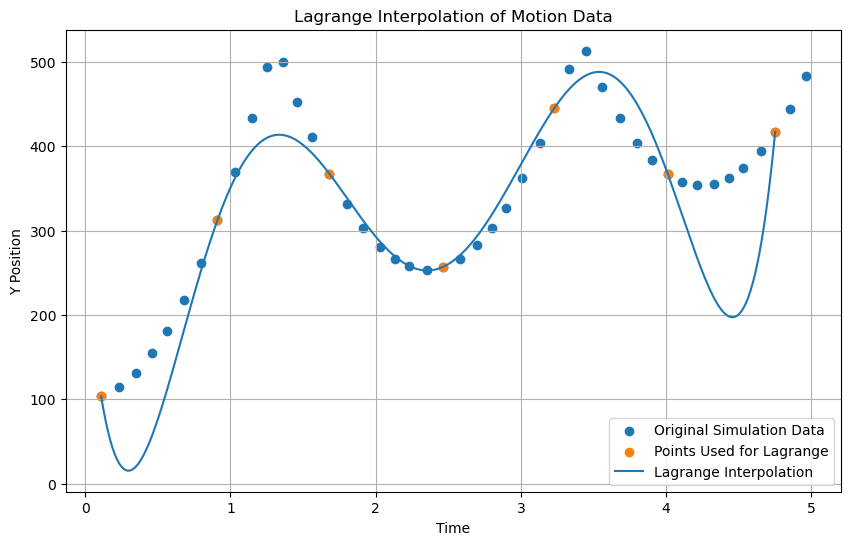

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read the dataset
data = pd.read_csv("analysis/motion_data.csv")

# Use fewer points for Lagrange interpolation
# because using all points creates a very high-degree polynomial
# and causes huge oscillations.
data_subset = data.iloc[::7]

# Get selected time and y-position values
t_values = data_subset["time"].values
y_values = data_subset["y"].values

# Lagrange interpolation function
def lagrange_interpolation(x, t_values, y_values):
    result = 0
    n = len(t_values)

    for i in range(n):
        term = y_values[i]

        for j in range(n):
            if i != j:
                term = term * (x - t_values[j]) / (t_values[i] - t_values[j])

        result = result + term

    return result

# Generate smooth time values for plotting
t_smooth = np.linspace(min(t_values), max(t_values), 300)

y_lagrange = []
for t in t_smooth:
    y_lagrange.append(lagrange_interpolation(t, t_values, y_values))

# Plot using Matplotlib
plt.figure(figsize=(10, 6))

# Plot all original simulation data
plt.scatter(data["time"], data["y"], label="Original Simulation Data")

# Plot the selected points used in Lagrange
plt.scatter(t_values, y_values, label="Points Used for Lagrange")

# Plot Lagrange interpolation curve
plt.plot(t_smooth, y_lagrange, label="Lagrange Interpolation")

plt.xlabel("Time")
plt.ylabel("Y Position")
plt.title("Lagrange Interpolation of Motion Data")
plt.legend()
plt.grid(True)
plt.show()

In [3]:
# Calculate Lagrange predicted values at the selected points
predicted_y = []

for t in t_values:
    predicted_y.append(lagrange_interpolation(t, t_values, y_values))

# Create error table
error_table = pd.DataFrame({
    "Time": t_values,
    "Actual Y": y_values,
    "Lagrange Predicted Y": predicted_y
})

# Absolute error
error_table["Absolute Error"] = abs(
    error_table["Actual Y"] - error_table["Lagrange Predicted Y"]
)

# Relative percent error
error_table["Relative Percent Error (%)"] = abs(
    (error_table["Actual Y"] - error_table["Lagrange Predicted Y"])
    / error_table["Actual Y"]
) * 100

error_table

,Time,Actual Y,Lagrange Predicted Y,Absolute Error,Relative Percent Error (%)
0,0.11,103.66,103.66,0.000000e+00,0.000000e+00
1,0.91,312.07,312.07,0.000000e+00,0.000000e+00
2,1.68,367.69,367.69,0.000000e+00,0.000000e+00
3,2.46,256.72,256.72,0.000000e+00,0.000000e+00
4,3.23,445.31,445.31,5.684342e-14,1.276491e-14
5,4.01,367.39,367.39,0.000000e+00,0.000000e+00
6,4.75,416.84,416.84,5.684342e-14,1.363675e-14


    Time  Actual Y  Predicted Y  Absolute Error  Relative Percent Error (%)
0   0.11    103.66   109.552245        5.892245                    5.684203
1   0.23    114.14   144.832990       30.692990                   26.890652
2   0.35    131.41   176.901097       45.491097                   34.617683
3   0.46    155.41   203.599339       48.189339                   31.007875
4   0.56    181.47   225.729005       44.259005                   24.389158
5   0.68    218.15   249.715155       31.565155                   14.469473
6   0.80    261.71   271.036159        9.326159                    3.563547
7   0.91    312.07   288.363847       23.706153                    7.596422
8   1.03    369.11   304.984737       64.125263                   17.372941
9   1.15    433.04   319.366308      113.673692                   26.250160
10  1.25    493.44   329.745689      163.694311                   33.174107
11  1.36    499.92   339.584828      160.335172                   32.072166
12  1.46    

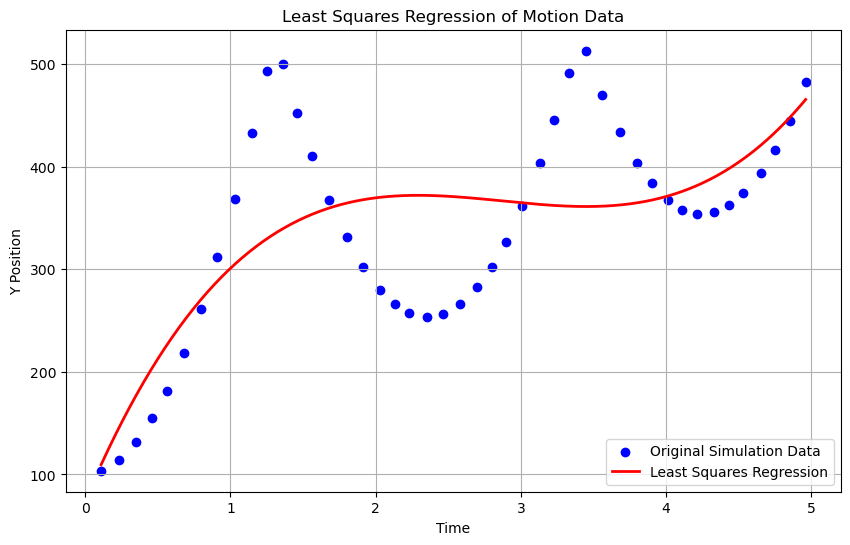

In [8]:


t = data["time"].values
y = data["y"].values

# =========================
# LEAST SQUARES REGRESSION
# =========================
# Polynomial degree
degree = 3

# Fit polynomial using least squares
coeffs = np.polyfit(t, y, degree)

# Create polynomial function
poly = np.poly1d(coeffs)

# Predict values
y_pred = poly(t)

# =========================
# ERROR CALCULATIONS
# =========================
absolute_error = np.abs(y - y_pred)

relative_percent_error = np.abs((y - y_pred) / y) * 100

# Mean errors
mae = np.mean(absolute_error)
mre = np.mean(relative_percent_error)

# =========================
# ERROR TABLE
# =========================
error_table = pd.DataFrame({
    "Time": t,
    "Actual Y": y,
    "Predicted Y": y_pred,
    "Absolute Error": absolute_error,
    "Relative Percent Error (%)": relative_percent_error
})

print(error_table)

print("\nMean Absolute Error =", mae)
print("Mean Relative Percent Error (%) =", mre)

# =========================
# PLOT RESULTS
# =========================
plt.figure(figsize=(10,6))

# Original data
plt.scatter(t, y, color='blue', label='Original Simulation Data')

# Least squares curve
t_smooth = np.linspace(min(t), max(t), 500)
plt.plot(t_smooth, poly(t_smooth),
         color='red',
         linewidth=2,
         label='Least Squares Regression')

plt.xlabel("Time")
plt.ylabel("Y Position")
plt.title("Least Squares Regression of Motion Data")

plt.legend()
plt.grid(True)

plt.show()

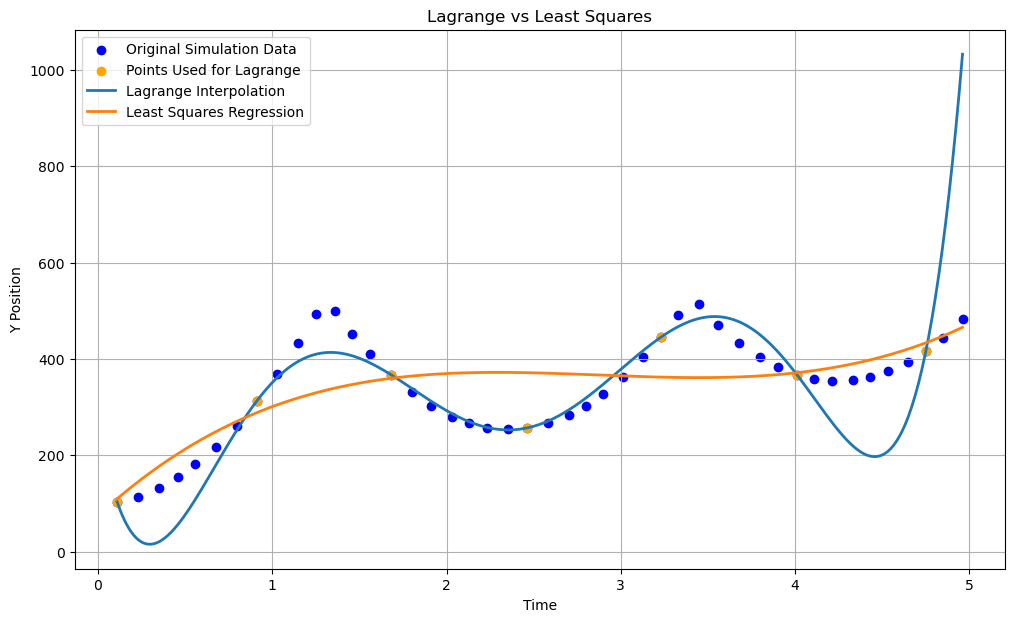

Lagrange Mean Error = 54.57167769999205
Least Squares Mean Error = 60.16861069361029

Lagrange Interpolation is better for this dataset.
Reason: it gives smaller error and passes through selected points exactly.


In [ ]:
t = data["time"].values
y = data["y"].values

# =========================
# LAGRANGE INTERPOLATION
# =========================
# Use selected points to reduce oscillation
data_subset = data.iloc[::7]

t_sub = data_subset["time"].values
y_sub = data_subset["y"].values

def lagrange_interpolation(x_points, y_points, x_values):
    n = len(x_points)
    p = np.zeros_like(x_values, dtype=float)

    for i in range(n):
        term = np.ones_like(x_values, dtype=float)

        for j in range(n):
            if i != j:
                term *= (x_values - x_points[j]) / (x_points[i] - x_points[j])

        p += y_points[i] * term

    return p

# Smooth plotting points
t_smooth = np.linspace(min(t), max(t), 500)

# Lagrange curve
y_lagrange = lagrange_interpolation(t_sub, y_sub, t_smooth)

# =========================
# LEAST SQUARES REGRESSION
# =========================
degree = 3

coeffs = np.polyfit(t, y, degree)

least_squares_poly = np.poly1d(coeffs)

y_least_squares = least_squares_poly(t_smooth)

# =========================
# ERROR COMPARISON
# =========================
# Predictions on original points
y_lagrange_pred = lagrange_interpolation(t_sub, y_sub, t)
y_ls_pred = least_squares_poly(t)

# Mean Absolute Error
lagrange_error = np.mean(np.abs(y - y_lagrange_pred))
least_squares_error = np.mean(np.abs(y - y_ls_pred))

# =========================
# PLOT
# =========================
plt.figure(figsize=(12,7))

# Original data
plt.scatter(t, y, color='blue', label='Original Simulation Data')

# Selected points for Lagrange
plt.scatter(t_sub, y_sub, color='orange',
            label='Points Used for Lagrange')

# Lagrange curve
plt.plot(t_smooth, y_lagrange,
         linewidth=2,
         label='Lagrange Interpolation')

# Least squares curve
plt.plot(t_smooth, y_least_squares,
         linewidth=2,
         label='Least Squares Regression')

plt.xlabel("Time")
plt.ylabel("Y Position")
plt.title("Lagrange vs Least Squares")
plt.grid(True)
plt.legend()

plt.show()

# =========================
# WHICH IS BETTER?
# =========================
print("Lagrange Mean Error =", lagrange_error)
print("Least Squares Mean Error =", least_squares_error)

if least_squares_error < lagrange_error:
    print("\nLeast Squares Regression is better for this dataset.")
    print("Reason: it produces a smoother curve and follows the overall motion trend.")
else:
    print("\nLagrange Interpolation is better for this dataset.")
    print("Reason: it gives smaller error and passes through selected points exactly.")